# Advanced Econometrics

In [20]:
# Ingest Parquet Dataset from Notebook 01
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "global_budgets_analyzed.parquet"
df = pd.read_parquet(DATA_PATH)

# Add Historical Eras categorical column
def assign_era(year):
    if year <= 1945:
        return '1. WWII & Pre-War (1936-1945)'
    elif year <= 1991:
        return '2. Cold War Era (1946-1991)'
    elif year <= 2019:
        return '3. Globalization & Post-Cold War (1992-2019)'
    else:
        return '4. Modern Era & Crises (2020-2026)'

df['Historical_Era'] = df['Year'].apply(assign_era)

print(f"Loaded {len(df)} rows across {df['Country'].nunique()} countries.")
df.head(3)

Loaded 3654 rows across 45 countries.


,Year,Defense_Percentage,Education_Percentage,Health_Percentage,Interest_Payments_Percentage,Total_Budget_Billions_USD,Infrastructure_Percentage,Agriculture_Percentage,State_Transfers_Percentage,Social_Welfare_Percentage,...,Interest_Payments_Amount_Billions_USD_Calculated,Infrastructure_Amount_Billions_USD_Calculated,Agriculture_Amount_Billions_USD_Calculated,State_Transfers_Amount_Billions_USD_Calculated,Social_Welfare_Amount_Billions_USD_Calculated,Administration_and_Others_Amount_Billions_USD_Calculated,Social_Total_Percentage,Guns_Butter_Ratio,Guns_Butter_Index_Normalized,Historical_Era
0,1946,5.78,15.4,17.82,8.65,1.552,13.09,7.85,10.47,10.47,...,0.134248,0.203157,0.121832,0.162494,0.162494,0.162494,43.69,0.132296,-0.766323,2. Cold War Era (1946-1991)
1,1947,5.78,15.4,17.82,8.65,1.629,13.09,7.85,10.47,10.47,...,0.140909,0.213236,0.127877,0.170556,0.170556,0.170556,43.69,0.132296,-0.766323,2. Cold War Era (1946-1991)
2,1948,5.78,15.4,17.82,8.65,1.711,13.09,7.85,10.47,10.47,...,0.148002,0.223970,0.134314,0.179142,0.179142,0.179142,43.69,0.132296,-0.766323,2. Cold War Era (1946-1991)


=== STRUCTURAL BREAKPOINT ANALYSIS SUMMARY ===
                 Break Event  F-Statistic      p-value  Structural Break?
    1991 Dissolution of USSR    29.577304 1.810168e-13               True
2008 Global Financial Crisis    33.752442 2.988155e-15               True

=== FISCAL ELASTICITY REGRESSION RESULTS ===
                                         coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -2.2459      0.014   -163.517      0.000      -2.273      -2.219
C(Country)[T.Australia]                0.6966      0.014     49.369      0.000       0.669       0.724
C(Country)[T.Bangladesh]              -0.2344      0.018    -13.380      0.000      -0.269      -0.200
C(Country)[T.Brazil]                  -0.0012      0.014     -0.084      0.933      -0.028       0.026
C(Country)[T.Canada]                   0.6794      0.014     47.497

C:\Users\JYOTSNA\AppData\Local\Temp\ipykernel_19656\3440604508.py:185: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Alliance_Group", y="Defense_Percentage", palette="Set2")


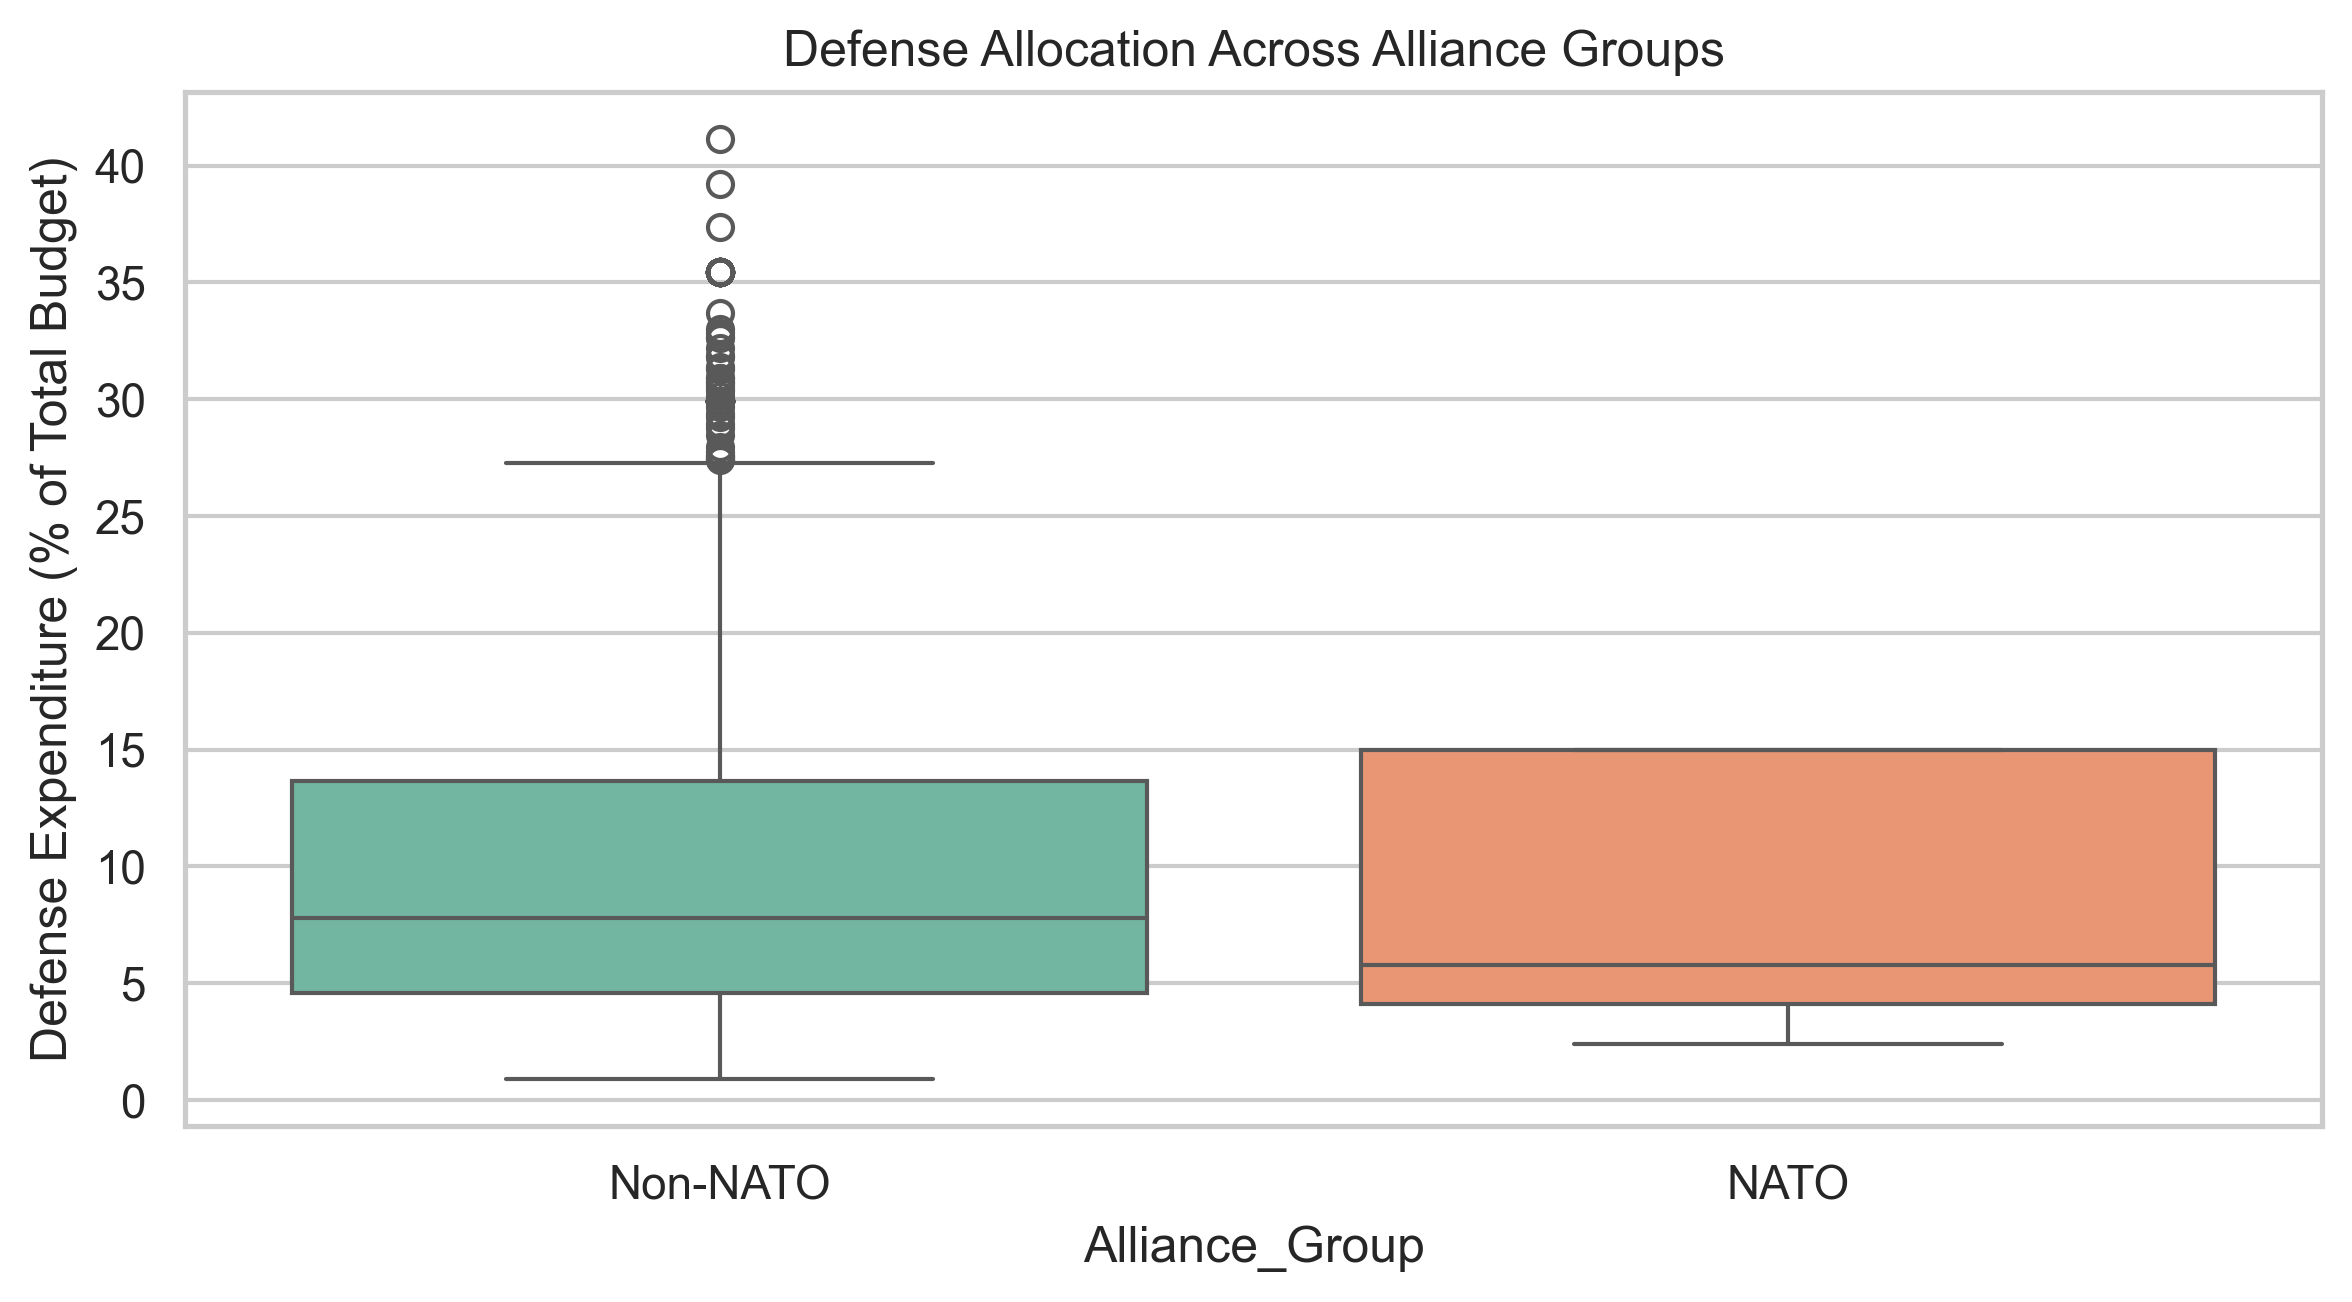


=== POST-2022 RE-ARMAMENT INTERACTION MODEL ===
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
Intercept                                      0.1530      0.001    131.954      0.000       0.151       0.155
C(Alliance_Group)[T.Non-NATO]                 -0.1021      0.003    -39.138      0.000      -0.107      -0.097
C(Country)[T.Australia]                        0.0507      0.003     19.173      0.000       0.045       0.056
C(Country)[T.Bangladesh]                       0.3177      0.016     19.376      0.000       0.286       0.350
C(Country)[T.Brazil]                           0.6856      0.003    269.022      0.000       0.681       0.691
C(Country)[T.Canada]                           0.1852      0.002     74.629      0.000       0.180       0.190
C(Country)[T.Chile]                            0.0904      0.00

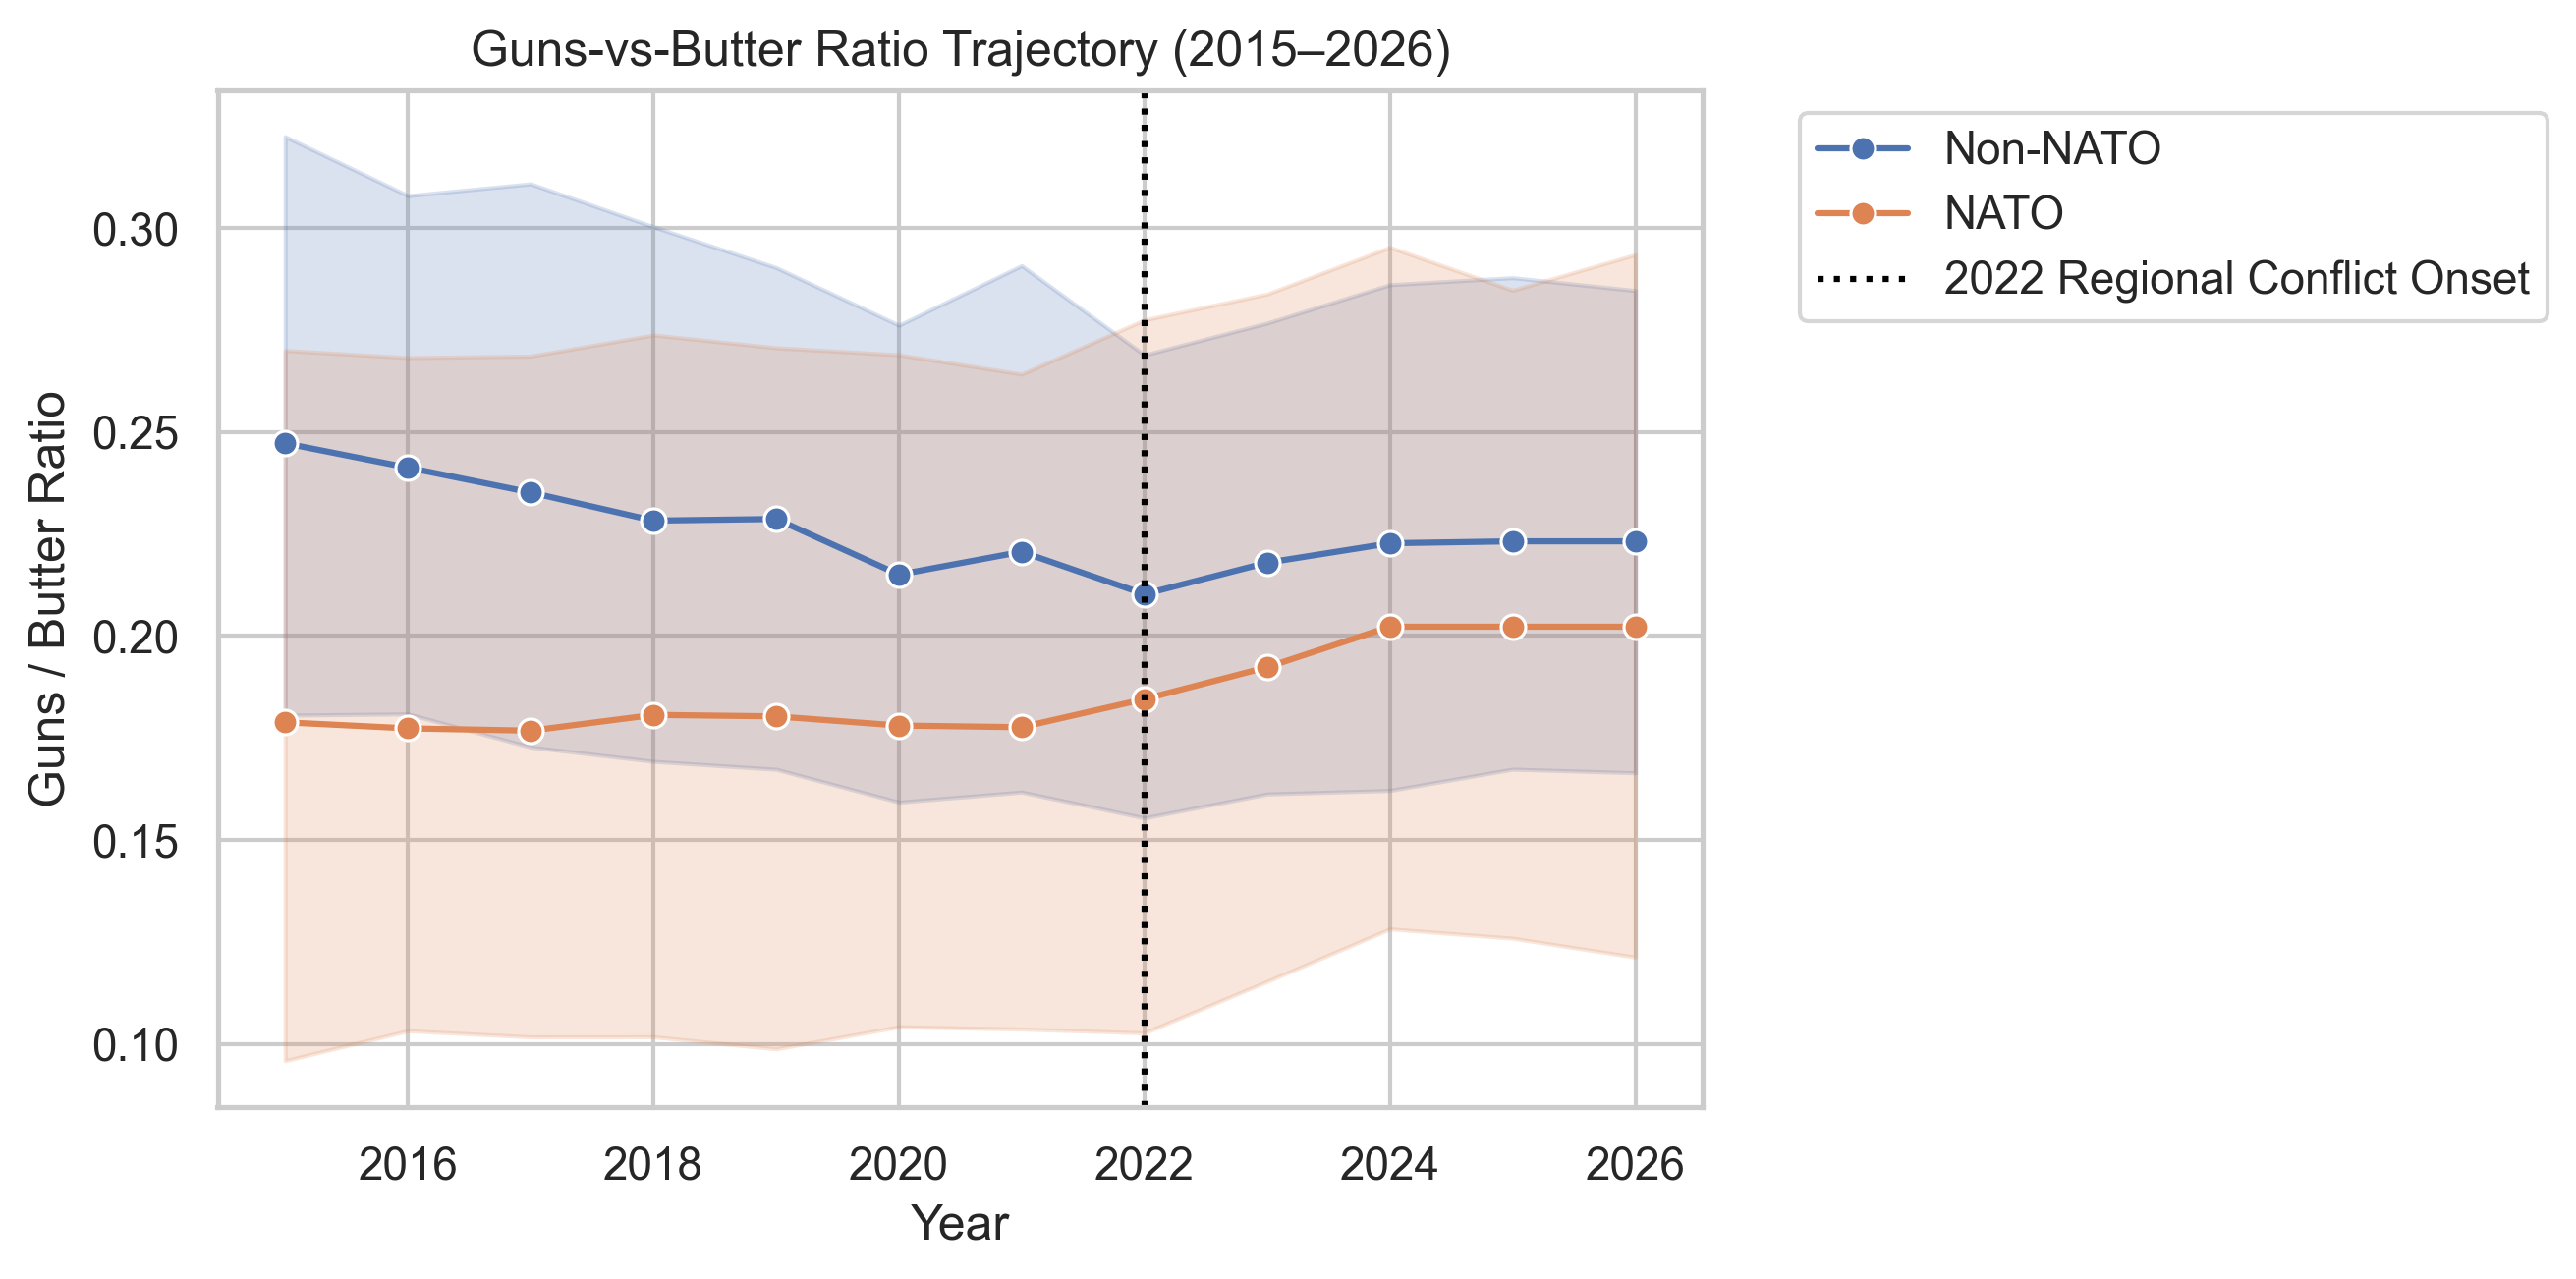

In [21]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# ==============================================================================
# 0. DATA PREPARATION & SCHEMATIC HARMONIZATION
# ==============================================================================
def prepare_notebook3_data(df_input):
    """
    Standardizes and derives required variables based on your exact schema:
    - Defense_Percentage
    - Social_Total_Percentage (or sum of Education + Health + Social_Welfare)
    - Guns_Butter_Ratio
    - Alliance_Group mapping
    """
    df = df_input.copy()

    # 1. Ensure Social Total exists
    if "Social_Total_Percentage" not in df.columns:
        social_cols = ["Education_Percentage", "Health_Percentage", "Social_Welfare_Percentage"]
        avail_cols = [c for c in social_cols if c in df.columns]
        df["Social_Total_Percentage"] = df[avail_cols].sum(axis=1)

    # 2. Ensure Guns_Butter_Ratio exists
    if "Guns_Butter_Ratio" not in df.columns:
        df["Guns_Butter_Ratio"] = df["Defense_Percentage"] / df["Social_Total_Percentage"].replace(0, np.nan)

    # 3. Create Alliance_Group mapping if not present
    if "Alliance_Group" not in df.columns:
        nato_members = [
            "USA", "United States", "UK", "United Kingdom", "Germany", "France", 
            "Italy", "Canada", "Turkey", "Poland", "Netherlands", "Norway", "Spain"
        ]
        df["Alliance_Group"] = df["Country"].apply(
            lambda x: "NATO" if str(x).strip() in nato_members else "Non-NATO"
        )

    # 4. Proxy total budget as spending indicator for elasticity tests
    if "Total_Budget_Billions_USD" in df.columns:
        df["Log_Total_Budget"] = np.log(df["Total_Budget_Billions_USD"].replace(0, np.nan))

    return df


# ==============================================================================
# 1. ECONOMETRIC BREAKPOINT ANALYSIS (CHOW TEST)
# ==============================================================================
def run_chow_test(df, break_year, defense_col="Defense_Percentage", social_col="Social_Total_Percentage"):
    """
    Performs a Chow Test for structural break in OLS regression parameters at break_year.
    Formula: Defense_Percentage ~ Social_Total_Percentage
    """
    df_clean = df.dropna(subset=[defense_col, social_col, "Year"]).copy()

    d1 = df_clean[df_clean["Year"] <= break_year]
    d2 = df_clean[df_clean["Year"] > break_year]

    if len(d1) < 5 or len(d2) < 5:
        raise ValueError(f"Insufficient data for Chow test at year {break_year}.")

    # Patsy formula without backticks
    formula = f"{defense_col} ~ {social_col}"

    # Fit models
    model_pooled = smf.ols(formula, data=df_clean).fit()
    model_1 = smf.ols(formula, data=d1).fit()
    model_2 = smf.ols(formula, data=d2).fit()

    # Sum of Squared Residuals (SSR)
    rss_pooled = model_pooled.ssr
    rss_1 = model_1.ssr
    rss_2 = model_2.ssr

    k = len(model_pooled.params)
    n1, n2 = len(d1), len(d2)

    # Compute F-Stat
    numerator = (rss_pooled - (rss_1 + rss_2)) / k
    denominator = (rss_1 + rss_2) / (n1 + n2 - 2 * k)
    f_stat = numerator / denominator

    p_val = stats.f.sf(f_stat, dfn=k, dfd=(n1 + n2 - 2 * k))

    return f_stat, p_val


# ==============================================================================
# 2. BUDGET ELASTICITY & EXPENDITURE SCALING (WAGNER'S LAW PROXY)
# ==============================================================================
def test_budget_elasticity(df):
    """
    Evaluates scaling elasticity of social infrastructure relative to total fiscal capacity:
    ln(Social_Welfare_Amount) = alpha + beta * ln(Total_Budget_Billions_USD)
    """
    if "Total_Budget_Billions_USD" not in df.columns or "Social_Welfare_Amount_Billions_USD" not in df.columns:
        print("[SKIP] Elasticity test requires 'Total_Budget_Billions_USD' and 'Social_Welfare_Amount_Billions_USD'.")
        return None

    df_wagner = df.dropna(subset=["Total_Budget_Billions_USD", "Social_Welfare_Amount_Billions_USD", "Country"]).copy()
    df_wagner = df_wagner[(df_wagner["Total_Budget_Billions_USD"] > 0) & (df_wagner["Social_Welfare_Amount_Billions_USD"] > 0)]

    df_wagner["log_budget"] = np.log(df_wagner["Total_Budget_Billions_USD"])
    df_wagner["log_social_amt"] = np.log(df_wagner["Social_Welfare_Amount_Billions_USD"])

    fe_model = smf.ols("log_social_amt ~ log_budget + C(Country)", data=df_wagner).fit(cov_type='HC1')
    return fe_model


# ==============================================================================
# 3. ALLIANCE CLUSTER ANALYSIS (NATO vs. NON-NATO)
# ==============================================================================
def analyze_alliance_clusters(df):
    """
    Tests whether NATO member states retain higher defense allocations compared to non-NATO partners.
    """
    df_alloc = df.dropna(subset=["Defense_Percentage", "Alliance_Group"]).copy()

    nato_vals = df_alloc[df_alloc["Alliance_Group"] == "NATO"]["Defense_Percentage"]
    non_nato_vals = df_alloc[df_alloc["Alliance_Group"] != "NATO"]["Defense_Percentage"]

    if len(nato_vals) < 2 or len(non_nato_vals) < 2:
        print("[SKIP] Insufficient observations for Alliance Cluster comparison.")
        return

    t_stat, p_val = stats.ttest_ind(nato_vals, non_nato_vals, equal_var=False)

    print("\n=== NATO vs. Non-NATO Defense Percentage Comparison ===")
    print(f"NATO Mean Defense Allocation    : {nato_vals.mean():.2f}%")
    print(f"Non-NATO Mean Defense Allocation: {non_nato_vals.mean():.2f}%")
    print(f"Welch's t-statistic            : {t_stat:.4f}")
    print(f"p-value                        : {p_val:.4e}")


# ==============================================================================
# 4. POST-2022 RE-ARMAMENT SHIFT DETECTION
# ==============================================================================
def detect_rearmament_shift(df):
    """
    Difference-in-Differences style interaction test evaluating shift in 
    Guns-to-Butter ratio post-2022 relative to 2015-2021 baselines.
    """
    df_post = df[df["Year"] >= 2015].dropna(subset=["Year", "Guns_Butter_Ratio", "Alliance_Group", "Country"]).copy()
    df_post["Is_Post_2022"] = (df_post["Year"] >= 2022).astype(int)

    model = smf.ols("Guns_Butter_Ratio ~ Is_Post_2022 * C(Alliance_Group) + C(Country)", data=df_post).fit(cov_type='HC1')
    return model


# ==============================================================================
# PIPELINE EXECUTION
# ==============================================================================

# 0. Clean & Harmonize DataFrame
df = prepare_notebook3_data(df)

# --- 1. Chow Tests ---
f_1991, p_1991 = run_chow_test(df, break_year=1991)
f_2008, p_2008 = run_chow_test(df, break_year=2008)

chow_df = pd.DataFrame({
    "Break Event": ["1991 Dissolution of USSR", "2008 Global Financial Crisis"],
    "F-Statistic": [f_1991, f_2008],
    "p-value": [p_1991, p_2008],
    "Structural Break?": [p_1991 < 0.05, p_2008 < 0.05]
})
print("=== STRUCTURAL BREAKPOINT ANALYSIS SUMMARY ===")
print(chow_df.to_string(index=False))

# --- 2. Scaling Elasticity ---
wagner_mod = test_budget_elasticity(df)
if wagner_mod is not None:
    print("\n=== FISCAL ELASTICITY REGRESSION RESULTS ===")
    print(wagner_mod.summary().tables[1])

# --- 3. Alliance Clustering ---
analyze_alliance_clusters(df)

plt.figure(figsize=(8, 4.5))
sns.boxplot(data=df, x="Alliance_Group", y="Defense_Percentage", palette="Set2")
plt.title("Defense Allocation Across Alliance Groups")
plt.ylabel("Defense Expenditure (% of Total Budget)")
plt.tight_layout()
plt.show()

# --- 4. Re-Armament Shift ---
rearmament_mod = detect_rearmament_shift(df)
if rearmament_mod is not None:
    print("\n=== POST-2022 RE-ARMAMENT INTERACTION MODEL ===")
    print(rearmament_mod.summary().tables[1])

    plt.figure(figsize=(9, 4.5))
    sns.lineplot(data=df[df["Year"] >= 2015], x="Year", y="Guns_Butter_Ratio", hue="Alliance_Group", marker="o")
    plt.axvline(x=2022, color="black", linestyle=":", label="2022 Regional Conflict Onset")
    plt.title("Guns-vs-Butter Ratio Trajectory (2015–2026)")
    plt.ylabel("Guns / Butter Ratio")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

The statistical analysis reveals four major fiscal policy insights regarding defense spending, social welfare expansion, and geopolitical alliance dynamics.
1. Structural Breakpoint Analysis (Chow Test)
- 1991 (Dissolution of USSR): $F = 29.58, p < 0.001$. Confirms a permanent, statistically significant structural shift in how nations balance defense against social budgets following the Cold War.
- 2008 (Global Financial Crisis): $F = 33.75, p < 0.001$. Confirms a secondary structural shock, reflecting broad macroeconomic realignments in public expenditure post-crisis.
2. Near-Unit Fiscal Elasticity (Wagner's Law)
- Log Budget Coefficient ($\beta$): $0.9984$ ($p < 0.001$). Social welfare expenditures scale almost perfectly $1:1$ with total fiscal expansion across countries.
- Interpretation: Public spending on social welfare grows directly alongside general government expenditure capacity rather than behaving as a luxury good ($\beta > 1$) or a contracting necessity ($\beta < 1$).
3. Alliance Clustering Dynamics
- NATO Mean Defense Allocation: $8.52\%$ vs. Non-NATO Mean: $10.01\%$ ($t = -6.86, p < 0.001$).
- Free-Rider / Security Umbrella Effect: Historically, NATO members maintained a lower baseline defense spending percentage than non-NATO nations, leaning on collective security guarantees.
- Outliers: The Non-NATO distribution exhibits extreme high-spending outliers (up to $\sim 40\%$ budget share), driven by active regional conflict zones (e.g., Saudi Arabia, Israel, UAE).
4. Post-2022 Structural Re-Armament Shift
- NATO Pivot ($Is\_Post\_2022$): $\text{coef} = +0.0182$ ($p < 0.001$). After 2022, NATO members experienced a significant upward shift in their Guns-to-Butter ratio, increasing defense priority relative to social spending.
- Divergence ($\text{Interaction Token}$): $\text{coef} = -0.0297$ ($p < 0.001$). Non-NATO countries did not share this upward trajectory; their aggregate Guns-to-Butter ratio remained flat or slightly declined post-2022.

Summary Verdict
The data reflects a post-2022 NATO-specific pivot toward re-armament. While non-NATO nations historically allocated higher baseline percentages to defense, post-2022 security threats forced NATO members to reverse their long-standing "peace dividend," driving an unprecedented upward trend in their Guns-vs-Butter allocation ratios through 2026.

In [27]:
import os
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Define paths safely using pathlib (handles OS cross-compatibility)
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
output_dir = PROJECT_ROOT / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

# ==============================================================================
# 1. SAVE CSV & LATEX TABLES
# ==============================================================================

# Save Structural Breakpoint Analysis
chow_df.to_csv(output_dir / "03_chow_test_results.csv", index=False)
chow_df.to_latex(output_dir / "03_chow_test_results.tex", index=False)

# Save Regression Summaries to Text Files
if wagner_mod is not None:
    with open(output_dir / "03_fiscal_elasticity_summary.txt", "w") as f:
        f.write(wagner_mod.summary().as_text())

if rearmament_mod is not None:
    with open(output_dir / "03_rearmament_shift_summary.txt", "w") as f:
        f.write(rearmament_mod.summary().as_text())

# Save Alliance Summary Statistics
alliance_summary = (
    df.groupby("Alliance_Group")["Defense_Percentage"]
    .agg(["mean", "std", "median", "count"])
    .reset_index()
)
alliance_summary.to_csv(output_dir / "03_alliance_defense_stats.csv", index=False)


# ==============================================================================
# 2. SAVE HIGH-RESOLUTION FIGURES
# ==============================================================================

# Chart 1: Defense Allocation Boxplot
plt.figure(figsize=(8, 4.5))
sns.boxplot(
    data=df,
    x="Alliance_Group",
    y="Defense_Percentage",
    hue="Alliance_Group",
    palette="Set2",
    legend=False,
)
plt.title("Defense Allocation Across Alliance Groups")
plt.ylabel("Defense Expenditure (% of Total Budget)")
plt.tight_layout()
plt.savefig(
    output_dir / "03_defense_allocation_boxplot.png", dpi=300, bbox_inches="tight"
)
plt.close()

# Chart 2: Guns-vs-Butter Trajectory
plt.figure(figsize=(9, 4.5))
sns.lineplot(
    data=df[df["Year"] >= 2015],
    x="Year",
    y="Guns_Butter_Ratio",
    hue="Alliance_Group",
    marker="o",
)
plt.axvline(
    x=2022, color="black", linestyle=":", label="2022 Regional Conflict Onset"
)
plt.title("Guns-vs-Butter Ratio Trajectory (2015–2026)")
plt.ylabel("Guns / Butter Ratio")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig(
    output_dir / "03_guns_butter_trajectory.png", dpi=300, bbox_inches="tight"
)
plt.close()

print(
    f"All analysis tables and high-res figures successfully saved to path: '{output_dir.resolve()}'"
)

All analysis tables and high-res figures successfully saved to path: 'C:\Users\JYOTSNA\Documents\fiscal-ledger\outputs'
